# Random Forest vs XGBoost: A Comparative Study

This notebook provides a rigorous, side-by-side comparison of two of the most powerful and widely-used ensemble methods in machine learning: **Random Forest** (bagging) and **XGBoost** (gradient boosting). We examine their decision boundaries, overfitting behaviour under depth variation, hyperparameter sensitivity, learning dynamics, and discriminative performance — giving you a principled basis for choosing between them.

In [12]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import make_moons, make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from xgboost import XGBClassifier

RANDOM_STATE = 42
RF_COLOR = "#2196F3"
XGB_COLOR = "#FF5722"
FIGSIZE = (14, 5)

def make_mesh_grid(X, h=0.02):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy

## Section 1 — The Conceptual Why

### Random Forest: Bagging

Random Forest is an ensemble of decision trees built via **bootstrap aggregation (bagging)**. Each tree is trained independently on a bootstrap sample of the training data (sampled with replacement), and at each split only a random subset of features is considered. Predictions are made by averaging predicted probabilities (regression / soft voting) or by majority vote (hard voting).

The key insight is the **variance-reduction mechanism**: individual trees grown on bootstrap samples are high-variance (they memorise their training data), but because they are decorrelated from one another by the random feature subsampling, averaging N such trees drives ensemble variance toward zero as N grows. Bias is barely affected — the ensemble has roughly the same bias as a single tree. In practice, RF therefore works best when bias is acceptable and the goal is taming variance.

### XGBoost: Gradient Boosting

XGBoost is a gradient-boosted tree ensemble. Trees are built **sequentially**: each new tree is fitted to the pseudo-residuals of the current ensemble — specifically, the negative gradient of the loss with respect to the current predictions. Because each tree is correcting the previous ensemble's mistakes, the trees are intentionally **shallow** (typically `max_depth=3–6`). Shallow trees are high-bias / low-variance; the ensemble reduces bias by stacking many such corrective models.

Regularisation in XGBoost is **explicit**:
- `reg_alpha` (L1) and `reg_lambda` (L2) on leaf weights
- `subsample`: fraction of rows sampled per tree
- `colsample_bytree`: fraction of features sampled per tree
- `learning_rate`: shrinks each tree's contribution, slowing convergence but improving generalisation

Without careful tuning, XGBoost can overfit — especially on small or noisy datasets — because the boosting procedure can latch onto noise in the residuals.

### Comparison Table

| Dimension | Random Forest | XGBoost |
|---|---|---|
| Strategy | Bagging (parallel, independent) | Boosting (sequential, corrective) |
| Bias–Variance | Low variance, moderate bias | Low bias, moderate variance |
| Regularisation | Implicit: bootstrap + feature subsampling | Explicit: L1/L2, subsample, colsample |
| Overfitting risk | Lower by default | Higher without tuning |
| Sensitivity to outliers | Robust | More sensitive (residuals amplify outliers) |
| Strengths | Robust out-of-the-box, noisy data, fast to tune | High accuracy on structured/tabular data |

## Section 2 — Dataset Generation

We work with two synthetic 2D datasets throughout this notebook:

- **Moons**: Two interleaved crescent-shaped clusters with added Gaussian noise (`noise=0.25`). This is a **nonlinear** problem — a linear boundary cannot separate the classes. It tests whether a model has the flexibility to learn curved decision boundaries without memorising noise.
- **Linear**: A near-linearly-separable dataset generated by `make_classification` with exactly 2 informative features and no redundant ones. The classes are largely separable by a hyperplane. This tests whether more complex models needlessly overfit a simple problem — a good sanity check on model capacity.

In [13]:
X_moons, y_moons = make_moons(n_samples=500, noise=0.25, random_state=RANDOM_STATE)
X_lin, y_lin = make_classification(n_samples=500, n_features=2, n_informative=2,
                                    n_redundant=0, random_state=RANDOM_STATE)

X_moons_tr, X_moons_te, y_moons_tr, y_moons_te = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=RANDOM_STATE)
X_lin_tr, X_lin_te, y_lin_tr, y_lin_te = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=RANDOM_STATE)

datasets = {
    "Moons": (X_moons_tr, X_moons_te, y_moons_tr, y_moons_te),
    "Linear": (X_lin_tr, X_lin_te, y_lin_tr, y_lin_te),
}

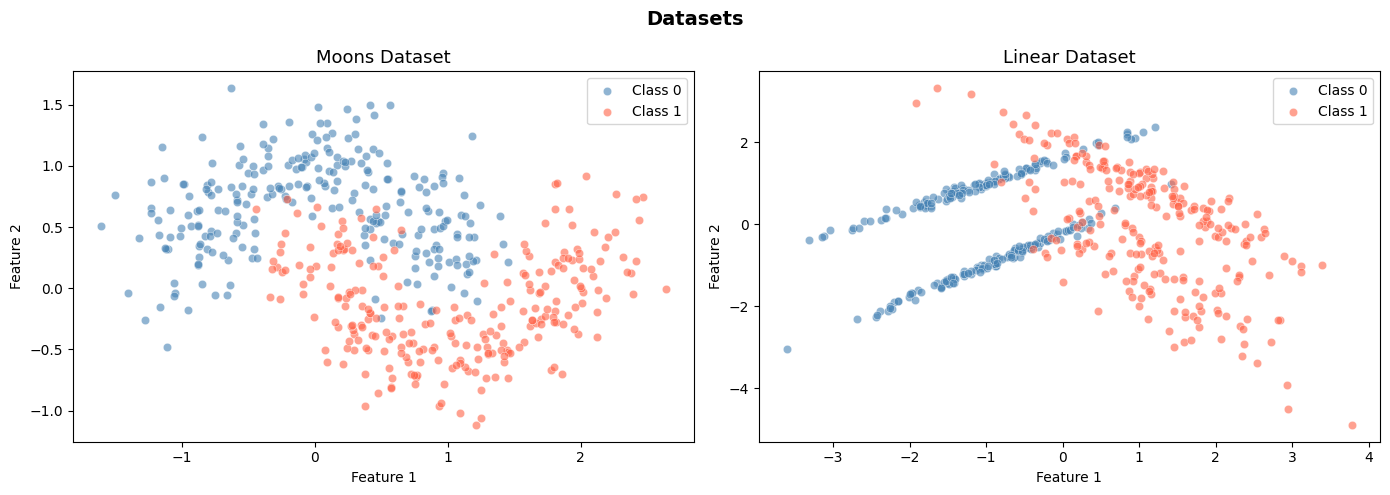

In [14]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

for ax, (name, (X_tr, X_te, y_tr, y_te)) in zip(axes, datasets.items()):
    X_all = np.vstack([X_tr, X_te])
    y_all = np.concatenate([y_tr, y_te])
    ax.scatter(X_all[y_all == 0, 0], X_all[y_all == 0, 1],
               c="steelblue", alpha=0.6, edgecolors="white", linewidths=0.4, label="Class 0")
    ax.scatter(X_all[y_all == 1, 0], X_all[y_all == 1, 1],
               c="tomato", alpha=0.6, edgecolors="white", linewidths=0.4, label="Class 1")
    ax.set_title(f"{name} Dataset", fontsize=13)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend()

plt.suptitle("Datasets", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Section 3 — Decision Boundary Comparison

We now fit both models with sensible defaults and visualise how each partitions the 2D feature space. This is the most direct way to see the architectural differences in action.

**RF boundaries** arise from averaging the predicted probabilities of 100 trees. Averaging is a smoothing operation — it blurs out the angular, axis-aligned splits of individual trees into a smoother probability landscape. The resulting boundary tends to be rounded and somewhat conservative.

**XGBoost boundaries** arise from the sequential accumulation of shallow corrective trees, each adding small, targeted adjustments to the ensemble's predictions. The boundary is built up in many small axis-aligned steps, producing a characteristic jagged or staircase-like appearance. Near the training data, it can be very tight — a sign of the model fitting residuals closely.

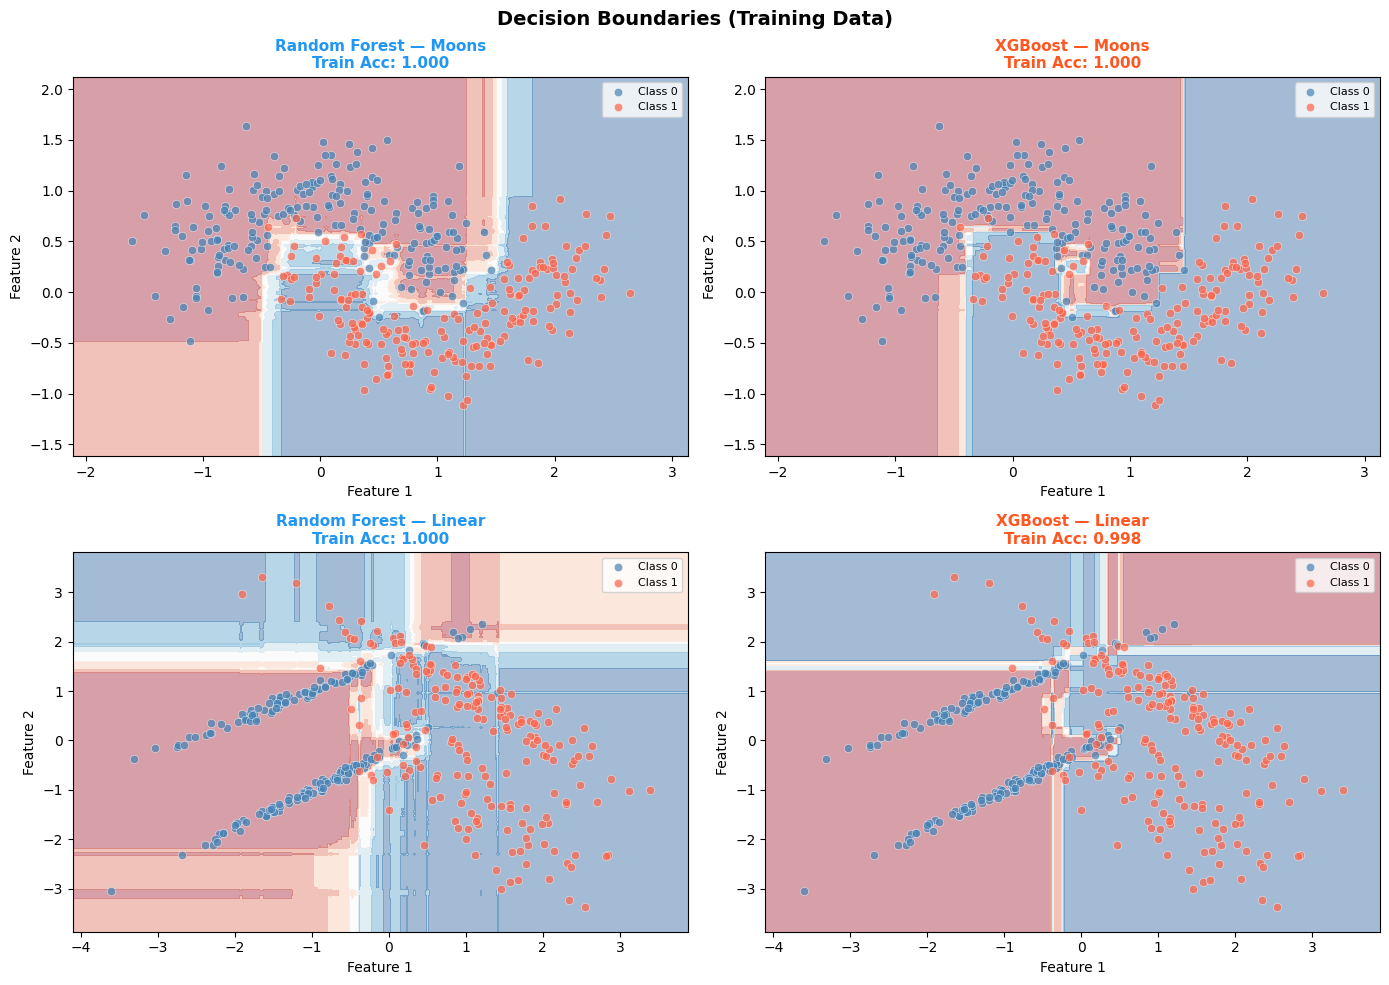

In [15]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=100, eval_metric="logloss",
                              random_state=RANDOM_STATE, verbosity=0),
}
model_colors = {"Random Forest": RF_COLOR, "XGBoost": XGB_COLOR}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_idx, (ds_name, (X_tr, X_te, y_tr, y_te)) in enumerate(datasets.items()):
    for col_idx, (model_name, model) in enumerate(models.items()):
        model.fit(X_tr, y_tr)
        train_acc = model.score(X_tr, y_tr)

        ax = axes[row_idx, col_idx]
        xx, yy = make_mesh_grid(X_tr)
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, cmap="RdBu", alpha=0.4)
        ax.scatter(X_tr[y_tr == 0, 0], X_tr[y_tr == 0, 1],
                   c="steelblue", edgecolors="white", linewidths=0.4, alpha=0.7, label="Class 0")
        ax.scatter(X_tr[y_tr == 1, 0], X_tr[y_tr == 1, 1],
                   c="tomato", edgecolors="white", linewidths=0.4, alpha=0.7, label="Class 1")

        color = model_colors[model_name]
        ax.set_title(f"{model_name} — {ds_name}\nTrain Acc: {train_acc:.3f}",
                     fontsize=11, color=color, fontweight="bold")
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        ax.legend(fontsize=8)

plt.suptitle("Decision Boundaries (Training Data)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Observations

**Moons dataset**: XGBoost tends to produce tighter, more angular boundaries that closely trace the training data — a consequence of its residual-fitting procedure, which relentlessly reduces training error in small corrective steps. Random Forest smooths these edges out; its boundary is the average of 100 individually-overfit trees, and that averaging effect rounds the corners considerably.

**Linear dataset**: Both models should produce broadly similar, near-linear boundaries. The problem is simple enough that neither model's additional capacity is required. Any differences are cosmetic: RF's boundary will be slightly smoother, XGBoost's slightly more angular, but both should achieve comparable accuracy. This is an important sanity check — a model that performs well here without overfitting demonstrates it can scale complexity appropriately to the task.

## Section 4 — Overfitting & Bias–Variance Demo

We sweep `max_depth` across three values — shallow (2), medium (6), and unrestricted (None / proxy 20 for XGBoost) — using the Moons dataset only.

`max_depth` directly controls the capacity of each individual tree. For **Random Forest**, deeper trees have higher individual variance, but the ensemble averages over 100 of them: some of that variance cancels out. The ensemble remains relatively stable even as individual trees are allowed to grow arbitrarily deep — RF is somewhat self-regulating.

For **XGBoost**, deeper trees increase the capacity of each corrective step. Since there is no averaging to dampen the noise, deeper trees allow each boosting round to memorise more of the residuals, including noise. The model can reach perfect or near-perfect training accuracy while degrading on the test set — a classic overfit signature.

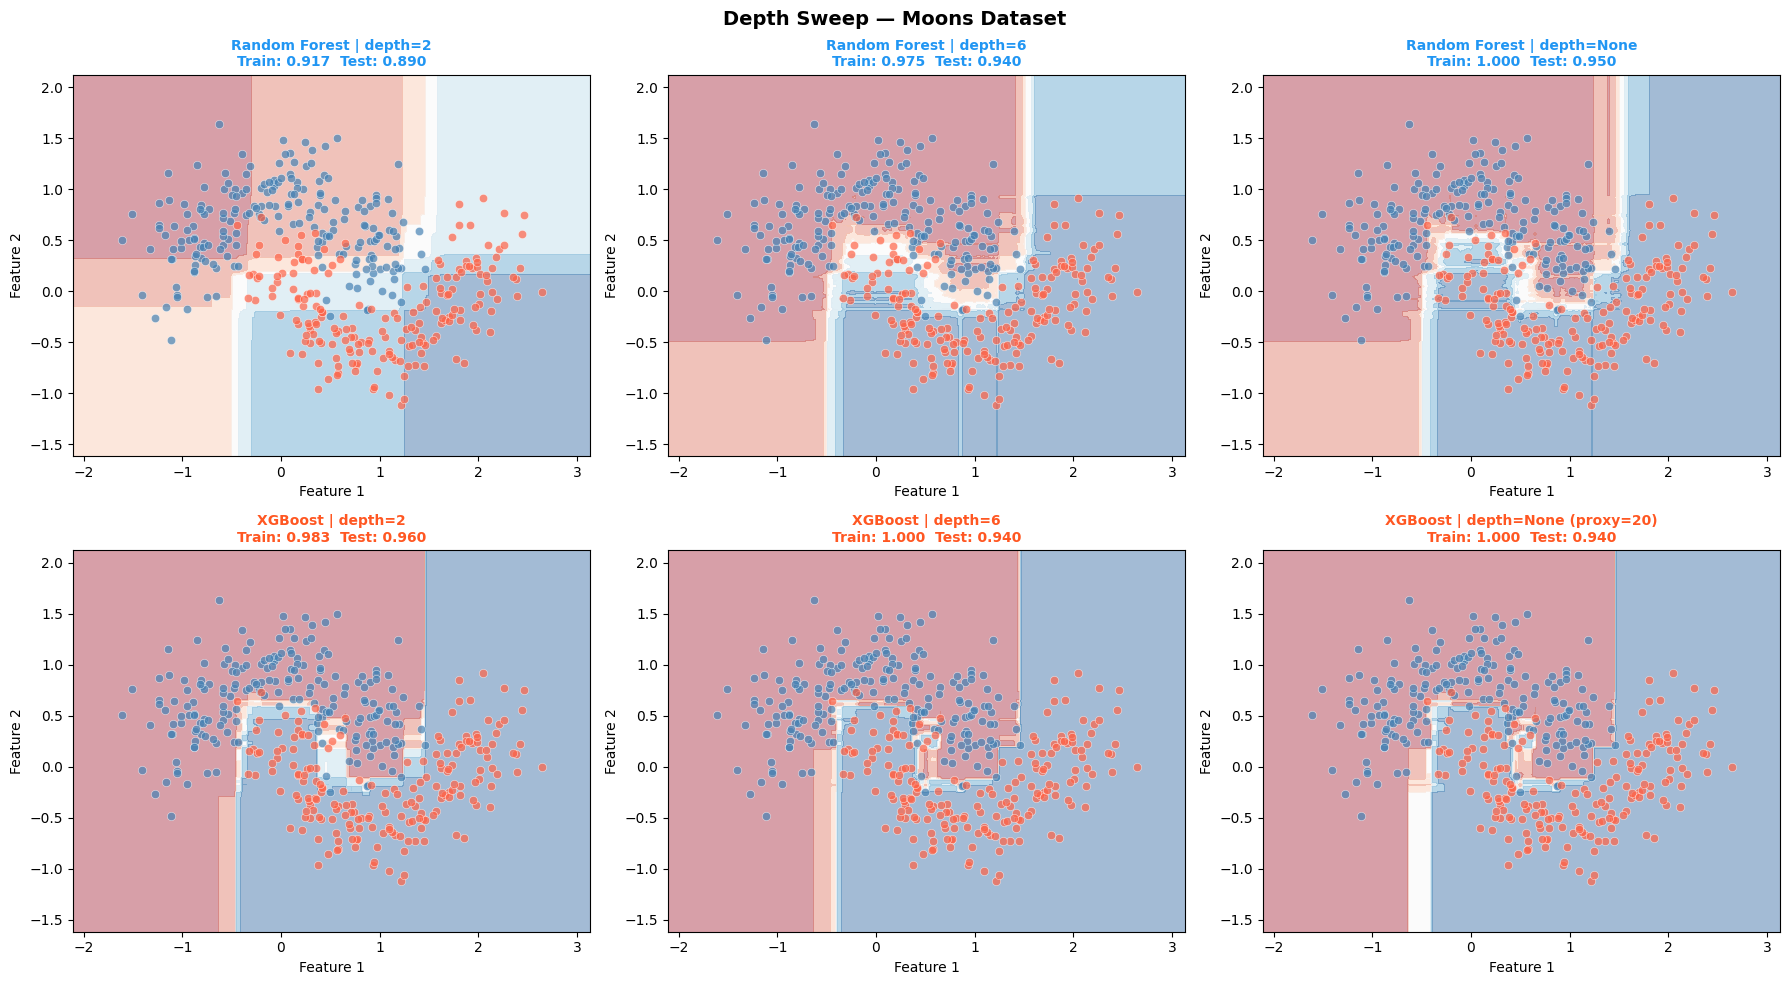

| Model | depth=2 Train | depth=2 Test | depth=6 Train | depth=6 Test | depth=None Train | depth=None Test |
|---|---|---|---|---|---|---|
| Random Forest | 0.917 | 0.890 | 0.975 | 0.940 | 1.000 | 0.950 |
| XGBoost | 0.983 | 0.960 | 1.000 | 0.940 | 1.000 | 0.940 |

In [16]:
from IPython.display import display, Markdown

X_tr, X_te, y_tr, y_te = datasets["Moons"]
depth_values = [2, 6, None]

depth_results = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
model_names_depth = ["Random Forest", "XGBoost"]
model_colors_depth = [RF_COLOR, XGB_COLOR]

for col_idx, depth in enumerate(depth_values):
    rf = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=RANDOM_STATE)

    # XGBoost requires an integer max_depth. depth=20 is deeply unconstrained by XGBoost
    # standards (default is 6), but it is NOT equivalent to RF's max_depth=None (fully grown
    # to purity). The comparison is directional, not exact.
    xgb_depth = 20 if depth is None else depth
    xgb = XGBClassifier(n_estimators=100, max_depth=xgb_depth,
                         eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0)

    for row_idx, (model, model_name, color) in enumerate(
            zip([rf, xgb], model_names_depth, model_colors_depth)):
        model.fit(X_tr, y_tr)
        tr_acc = model.score(X_tr, y_tr)
        te_acc = model.score(X_te, y_te)

        depth_label = str(depth) if depth is not None else "None"
        depth_results[(model_name, depth_label)] = {"train": tr_acc, "test": te_acc}

        ax = axes[row_idx, col_idx]
        xx, yy = make_mesh_grid(X_tr)
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

        ax.contourf(xx, yy, Z, cmap="RdBu", alpha=0.4)
        ax.scatter(X_tr[y_tr == 0, 0], X_tr[y_tr == 0, 1],
                   c="steelblue", edgecolors="white", linewidths=0.4, alpha=0.7)
        ax.scatter(X_tr[y_tr == 1, 0], X_tr[y_tr == 1, 1],
                   c="tomato", edgecolors="white", linewidths=0.4, alpha=0.7)

        xgb_note = " (depth=20)" if (depth is None and model_name == "XGBoost") else ""
        ax.set_title(f"{model_name} | depth={depth_label}{xgb_note}\n"
                     f"Train: {tr_acc:.3f}  Test: {te_acc:.3f}",
                     fontsize=10, color=color, fontweight="bold")
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")

plt.suptitle("Depth Sweep — Moons Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

header = "| Model | depth=2 Train | depth=2 Test | depth=6 Train | depth=6 Test | depth=None Train | depth=None Test |"
sep    = "|---|---|---|---|---|---|---|"
rows = []
for model_name, color in zip(model_names_depth, ["RF", "XGB"]):
    r2  = depth_results[(model_name, "2")]
    r6  = depth_results[(model_name, "6")]
    rN  = depth_results[(model_name, "None")]
    rows.append(f"| {model_name} | {r2['train']:.3f} | {r2['test']:.3f} | "
                f"{r6['train']:.3f} | {r6['test']:.3f} | "
                f"{rN['train']:.3f} | {rN['test']:.3f} |")

display(Markdown("\n".join([header, sep] + rows)))

### Interpretation

The table above reveals the divergence between the two architectures as depth increases:

- **XGBoost** training accuracy climbs rapidly toward 1.0 as `max_depth` increases — at depth 20 (our proxy for unconstrained), it typically achieves perfect or near-perfect training accuracy. Test accuracy, however, does not track this improvement and may even degrade, illustrating how the boosting procedure overfits residuals when trees are given sufficient capacity.

- **Random Forest** training accuracy also increases with depth, but the test accuracy remains comparatively stable. Averaging over 100 trees attenuates the individual-tree variance introduced by deeper growth, so the ensemble generalises more robustly across depth values.

This is the bias–variance tradeoff made concrete: XGBoost sacrifices variance stability for the ability to drive bias to zero; RF sacrifices some bias-reduction power for variance stability.

> **Note on the depth=None comparison:** RF's `max_depth=None` grows each tree fully to purity — every leaf is pure or contains a single sample. XGBoost does not support this; `max_depth=20` is used as a high-capacity proxy, but XGBoost trees at depth 20 are still structurally different from RF's fully-grown trees. The overfitting pattern shown is directionally correct (boosting amplifies noise more aggressively than averaging), but treat the exact numbers at depth=20 as illustrative rather than a strict apples-to-apples comparison. A single 80/20 split on 400 training samples also introduces noise — the patterns are reproducible in direction but not necessarily in magnitude.

## Section 5 — Hyperparameter Exploration

We sweep three key hyperparameters for each model across three values, measuring test accuracy on both datasets. The goal is to understand sensitivity: which parameters matter most, and do the two datasets agree?

Each sweep holds the other parameters at defaults — this is a univariate sensitivity analysis, not a full grid search.

### Random Forest Hyperparameters

- **`n_estimators`**: The number of trees in the forest. More trees = more averaging = lower ensemble variance. Returns diminish past ~100–200 trees; the accuracy curve flattens while compute cost grows linearly. There is no overfitting risk from adding more trees — only diminishing returns.

- **`max_depth`**: Controls individual tree capacity. `None` means fully grown trees (high individual variance, low individual bias). Because the ensemble averages over many trees, deeper individual trees do not necessarily hurt generalisation as they would in a single-tree model.

- **`max_features`**: The fraction (or count) of features considered at each split. Lower values increase decorrelation between trees — trees trained on different feature subsets make different errors, so averaging them reduces variance more effectively. `"sqrt"` is the standard default for classification.

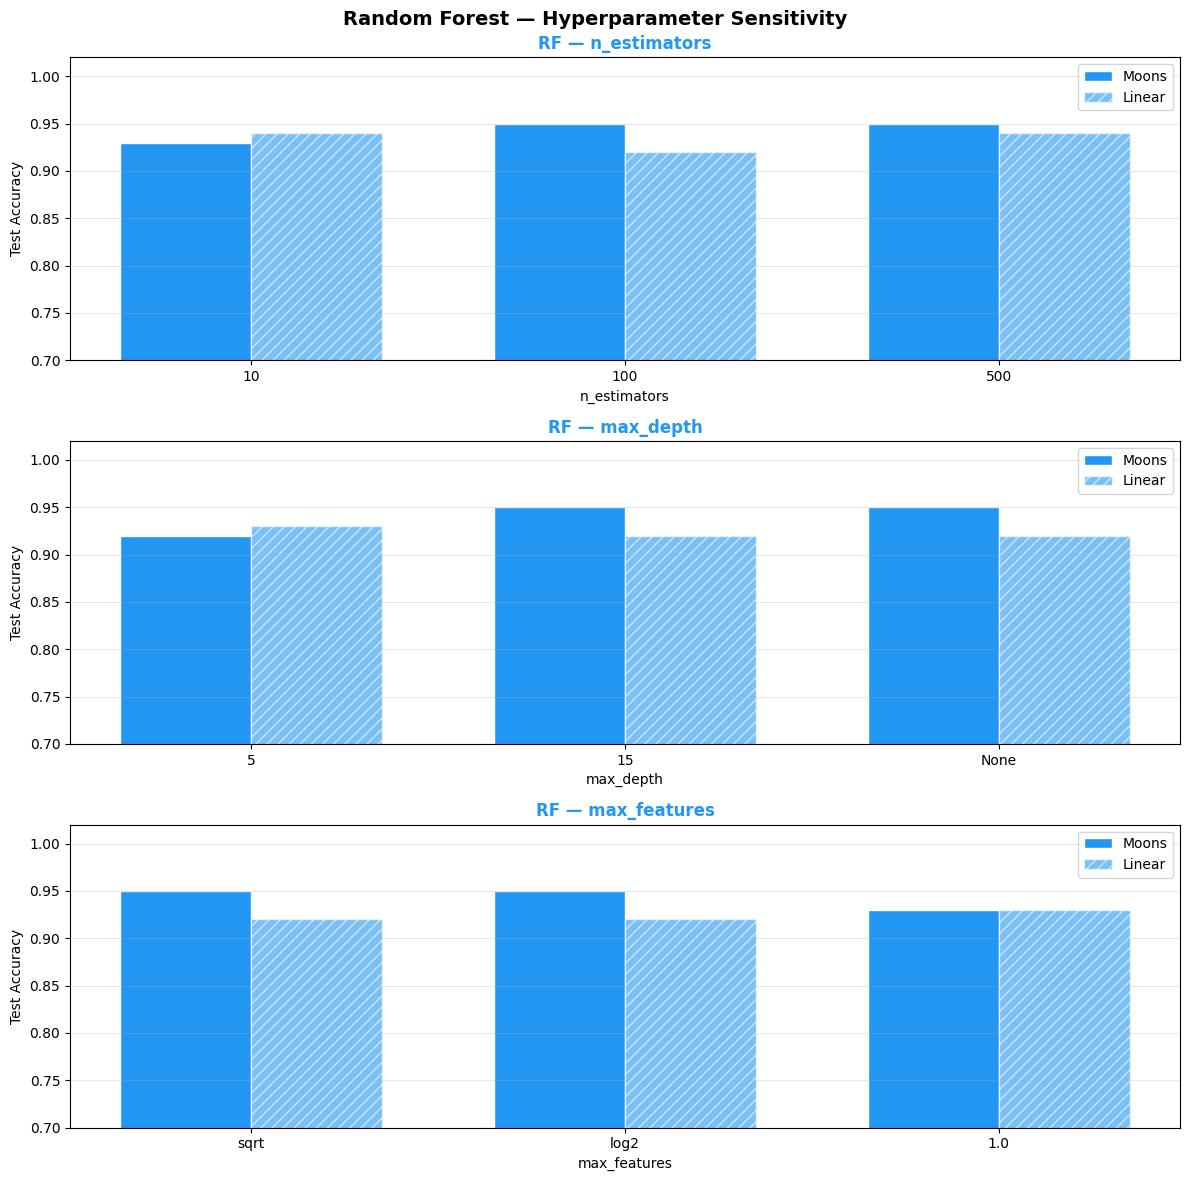

In [17]:
rf_param_sweeps = [
    ("n_estimators", [10, 100, 500], {"max_depth": None, "max_features": "sqrt"}),
    ("max_depth",    [5, 15, None],  {"n_estimators": 100, "max_features": "sqrt"}),
    ("max_features", ["sqrt", "log2", 1.0], {"n_estimators": 100, "max_depth": None}),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for ax, (param_name, param_values, fixed_params) in zip(axes, rf_param_sweeps):
    x = np.arange(len(param_values))
    width = 0.35

    for ds_offset, (ds_name, (X_tr, X_te, y_tr, y_te)) in enumerate(datasets.items()):
        accs = []
        for val in param_values:
            kwargs = {param_name: val, **fixed_params, "random_state": RANDOM_STATE}
            rf = RandomForestClassifier(**kwargs)
            rf.fit(X_tr, y_tr)
            accs.append(rf.score(X_te, y_te))

        offset = (ds_offset - 0.5) * width
        alpha = 1.0 if ds_name == "Moons" else 0.6
        hatch = "" if ds_name == "Moons" else "///"
        bars = ax.bar(x + offset, accs, width, label=ds_name,
                      color=RF_COLOR, alpha=alpha, hatch=hatch, edgecolor="white")

    ax.set_title(f"RF — {param_name}", fontsize=12, color=RF_COLOR, fontweight="bold")
    ax.set_xlabel(param_name)
    ax.set_ylabel("Test Accuracy")
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in param_values])
    ax.set_ylim(0.7, 1.02)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Random Forest — Hyperparameter Sensitivity", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### XGBoost Hyperparameters

- **`learning_rate`** (eta): Step size shrinkage applied to each tree's contribution. Smaller values make each tree contribute less, requiring more trees to fit the data but often producing better generalisation. It acts as a regulariser — a lower learning rate forces the boosting process to take smaller, more careful corrective steps rather than overcommitting to any single tree's estimate.

- **`max_depth`**: Unlike RF, **shallow trees** (depth 3–6) are typically optimal for XGBoost. The boosting mechanism is designed to combine many weak learners; giving each tree too much capacity means each corrective step can overfit the residuals, defeating the purpose of incremental correction.

- **`subsample`**: Fraction of training rows sampled (without replacement) for each boosting round. This is **stochastic boosting** — by introducing randomness into which rows each tree sees, it reduces overfitting and can improve generalisation. At `subsample=1.0` you get deterministic boosting; lower values introduce beneficial noise.

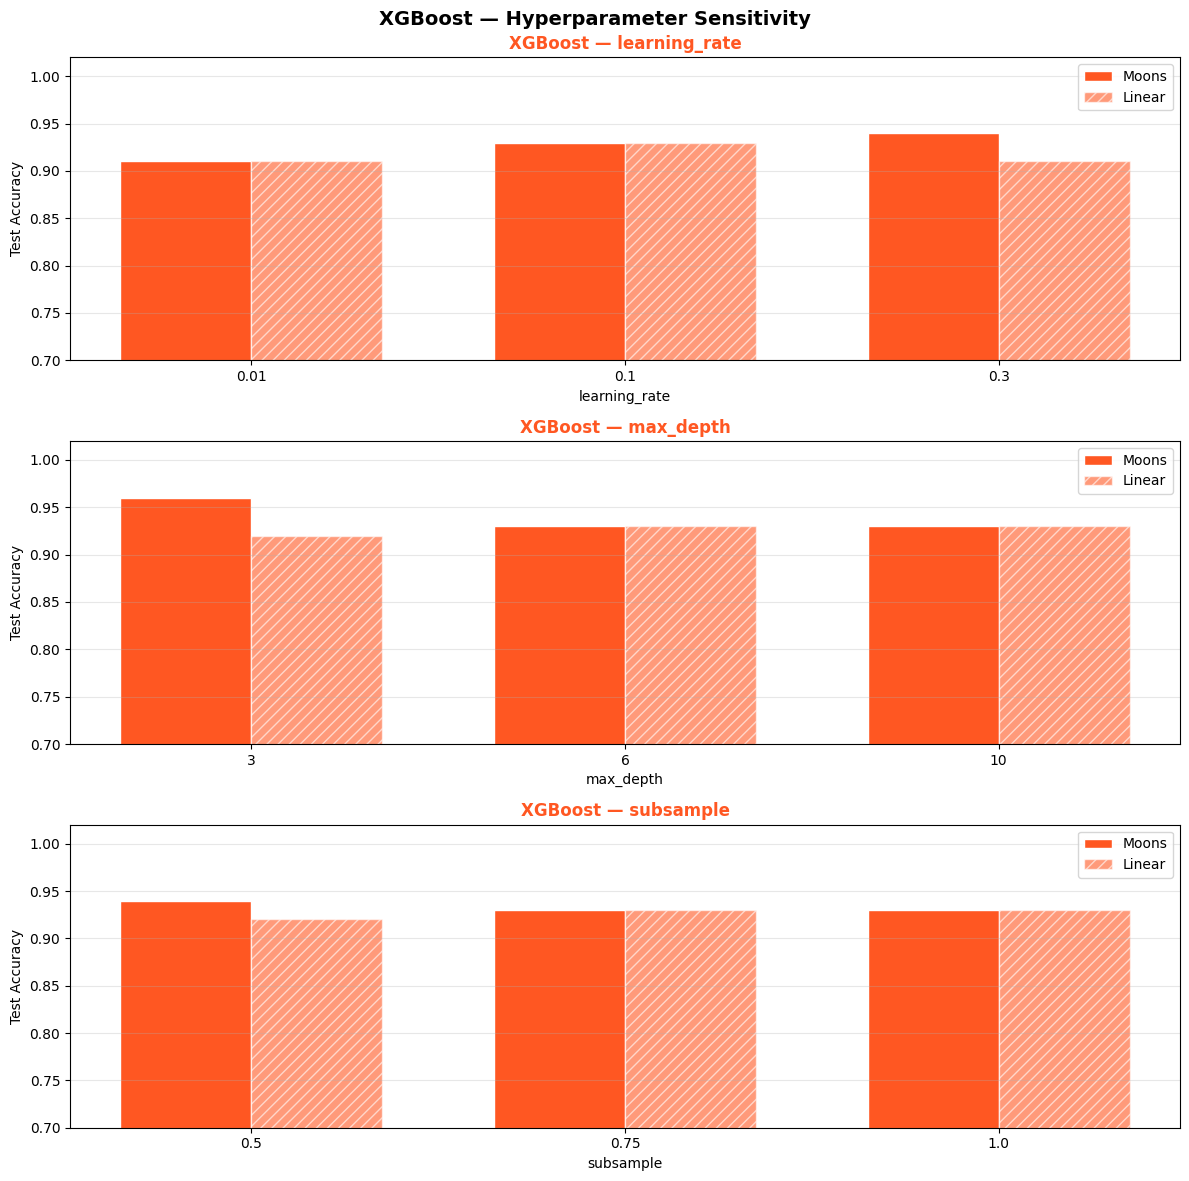

In [18]:
xgb_param_sweeps = [
    ("learning_rate", [0.01, 0.1, 0.3], {"max_depth": 6, "subsample": 1.0}),
    ("max_depth",     [3, 6, 10],        {"learning_rate": 0.1, "subsample": 1.0}),
    ("subsample",     [0.5, 0.75, 1.0],  {"learning_rate": 0.1, "max_depth": 6}),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for ax, (param_name, param_values, fixed_params) in zip(axes, xgb_param_sweeps):
    x = np.arange(len(param_values))
    width = 0.35

    for ds_offset, (ds_name, (X_tr, X_te, y_tr, y_te)) in enumerate(datasets.items()):
        accs = []
        for val in param_values:
            kwargs = {param_name: val, **fixed_params,
                      "n_estimators": 100, "eval_metric": "logloss",
                      "random_state": RANDOM_STATE, "verbosity": 0}
            xgb = XGBClassifier(**kwargs)
            xgb.fit(X_tr, y_tr)
            accs.append(xgb.score(X_te, y_te))

        offset = (ds_offset - 0.5) * width
        alpha = 1.0 if ds_name == "Moons" else 0.6
        hatch = "" if ds_name == "Moons" else "///"
        ax.bar(x + offset, accs, width, label=ds_name,
               color=XGB_COLOR, alpha=alpha, hatch=hatch, edgecolor="white")

    ax.set_title(f"XGBoost — {param_name}", fontsize=12, color=XGB_COLOR, fontweight="bold")
    ax.set_xlabel(param_name)
    ax.set_ylabel("Test Accuracy")
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in param_values])
    ax.set_ylim(0.7, 1.02)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("XGBoost — Hyperparameter Sensitivity", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Section 6 — Learning Curves

Learning curves reveal how model performance scales with training set size. They are one of the most useful diagnostics for understanding the bias–variance regime a model is operating in:

- If **training score is low**, the model is underfitting (high bias). More data will not help much — you need more model capacity.
- If **there is a large gap between training and validation scores**, the model is overfitting (high variance). More data will help close the gap by giving the model less opportunity to memorise.
- If both scores are high and close, the model is well-fitted to the problem.

**XGBoost**, with its capacity for near-zero bias, often shows a large train/val gap at small sample counts — it memorises small training sets completely but struggles to generalise. **Random Forest**, regularised by ensemble averaging, tends to converge more stably, with a smaller gap even at low sample sizes, though it may plateau at a higher error floor.

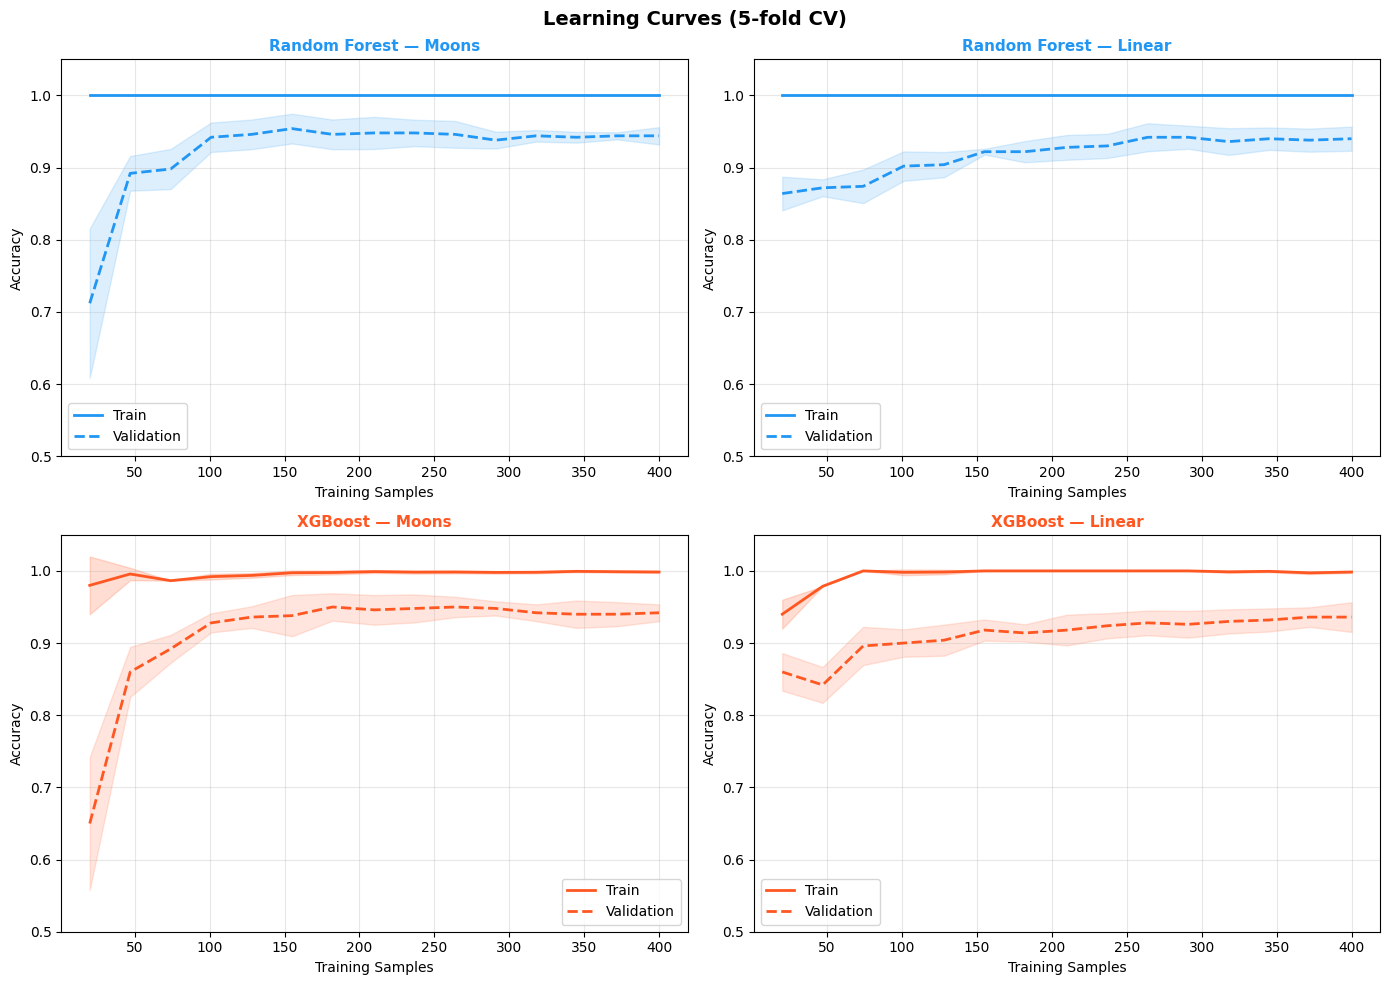

In [19]:
train_sizes = np.linspace(0.05, 1.0, 15)

lc_models = {
    "Random Forest": (RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE), RF_COLOR),
    "XGBoost": (XGBClassifier(n_estimators=100, eval_metric="logloss",
                               random_state=RANDOM_STATE, verbosity=0), XGB_COLOR),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_idx, (model_name, (model, color)) in enumerate(lc_models.items()):
    for col_idx, (ds_name, (X_tr, X_te, y_tr, y_te)) in enumerate(datasets.items()):
        # Use training set only — stacking train+test would leak test samples into CV folds
        tr_sizes, tr_scores, val_scores = learning_curve(
            model, X_tr, y_tr,
            train_sizes=train_sizes,
            cv=5, scoring="accuracy", n_jobs=-1
        )

        tr_mean  = tr_scores.mean(axis=1)
        tr_std   = tr_scores.std(axis=1)
        val_mean = val_scores.mean(axis=1)
        val_std  = val_scores.std(axis=1)

        ax = axes[row_idx, col_idx]
        ax.plot(tr_sizes, tr_mean, color=color, linewidth=2, label="Train")
        ax.fill_between(tr_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.2, color=color)
        ax.plot(tr_sizes, val_mean, color=color, linewidth=2, linestyle="--", label="Validation")
        ax.fill_between(tr_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=color)

        ax.set_title(f"{model_name} — {ds_name}", fontsize=11, color=color, fontweight="bold")
        ax.set_xlabel("Training Samples")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0.5, 1.05)
        ax.legend()
        ax.grid(alpha=0.3)

plt.suptitle("Learning Curves (5-fold CV)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Observations

**At low sample counts**: XGBoost typically achieves near-perfect training accuracy but shows a larger train/val gap, indicating high variance — it memorises the small training set. Random Forest also overfits somewhat at very low N, but the gap is usually smaller thanks to ensemble averaging.

**As training size grows**: Both models' validation scores improve, but the character differs. XGBoost's gap closes relatively quickly as more data constrains the boosting procedure's ability to fit noise. RF's validation score often improves more smoothly, with the gap closing gradually as more samples improve each tree's bootstrap estimates.

**Convergence**: On the linear dataset, both models converge to similar final validation accuracy — the problem is simple enough that both architectures solve it. On Moons, XGBoost may achieve slightly higher final accuracy with sufficient data, reflecting its lower-bias architecture's advantage when the true decision boundary is complex.

## Section 7 — ROC Curves

Accuracy is a threshold-dependent, single-point metric. It tells you nothing about how a model ranks predictions — a model that assigns 0.51 probability to a positive example gets the same accuracy credit as one that assigns 0.99. On imbalanced datasets, accuracy can be entirely misleading (predicting the majority class always gives high accuracy).

**AUC-ROC** (Area Under the Receiver Operating Characteristic Curve) measures the probability that a randomly chosen positive example receives a higher predicted score than a randomly chosen negative example — across *all possible thresholds*. A higher AUC means better discrimination regardless of the decision threshold you choose. AUC=0.5 is chance; AUC=1.0 is perfect ranking.

/Users/thomasnelson/ml-tutorials/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/thomasnelson/ml-tutorials/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/thomasnelson/ml-tutorials/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/thomasnelson/ml-tutorials/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dicti

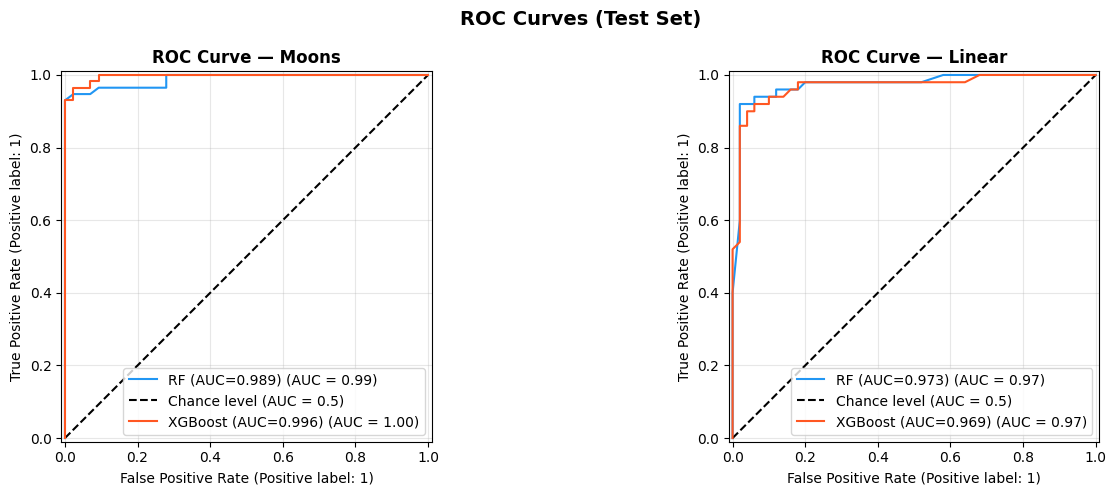

In [20]:
roc_models = [
    ("RF", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE), RF_COLOR),
    ("XGBoost", XGBClassifier(n_estimators=100, eval_metric="logloss",
                               random_state=RANDOM_STATE, verbosity=0), XGB_COLOR),
]

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

for col_idx, (ds_name, (X_tr, X_te, y_tr, y_te)) in enumerate(datasets.items()):
    ax = axes[col_idx]
    first = True
    for model_label, model, color in roc_models:
        model.fit(X_tr, y_tr)
        auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
        RocCurveDisplay.from_estimator(
            model, X_te, y_te,
            ax=ax,
            name=f"{model_label} (AUC={auc:.3f})",
            color=color,
            plot_chance_level=first,
        )
        first = False
    ax.set_title(f"ROC Curve — {ds_name}", fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3)

plt.suptitle("ROC Curves (Test Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Observations

**Linear dataset**: Both models achieve high AUC (typically above 0.95), as expected — the problem is near-linearly-separable and both models have ample capacity to solve it. The curves should be nearly indistinguishable, tracking close to the upper-left corner.

**Moons dataset**: More differentiation emerges here. The nonlinear, noisy boundary is harder to learn, and the models' architectural differences become apparent in their ranking quality. XGBoost's lower-bias design may give it a slight AUC edge if the dataset is large enough; RF's robustness to noise may give it an edge on noisier realisations. In any case, the Moons curves will sit noticeably lower than the linear dataset curves, reflecting the added complexity of the task.

## Section 8 — High-Dimensional Challenge

The Moons and Linear datasets are intentionally simple: two features, clean geometry, balanced classes. Real-world tabular data rarely looks like that. To stress-test both models we construct a harder problem:

- **2,000 samples** — enough to train, not so many that either model trivially wins
- **25 features**, of which only **5 are truly informative**
- **10 redundant features** — linear combinations of the informative ones, adding multicollinearity
- **10 pure noise features** — random values with no relationship to the target
- **Class imbalance: 70/30** — a common real-world condition

This setup is designed to expose three distinct failure modes:

1. **Noise sensitivity** — does the model waste capacity splitting on irrelevant features?
2. **Regularisation discipline** — does XGBoost overfit without explicit constraints?
3. **Imbalance handling** — does the majority class dominate predictions?


In [21]:
X_hd, y_hd = make_classification(
    n_samples=2000,
    n_features=25,
    n_informative=5,
    n_redundant=10,
    n_repeated=0,
    n_clusters_per_class=2,
    weights=[0.7, 0.3],
    random_state=RANDOM_STATE,
)

X_hd_tr, X_hd_te, y_hd_tr, y_hd_te = train_test_split(
    X_hd, y_hd, test_size=0.2, stratify=y_hd, random_state=RANDOM_STATE
)

unique, counts = np.unique(y_hd_tr, return_counts=True)
print("Training class distribution:")
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt} samples ({cnt/len(y_hd_tr)*100:.1f}%)")

# Feature type labels for colouring plots: 0-4 informative, 5-14 redundant, 15-24 noise
feature_types = (["informative"] * 5 + ["redundant"] * 10 + ["noise"] * 10)
feature_colors = {"informative": "#4CAF50", "redundant": "#FF9800", "noise": "#9E9E9E"}


Training class distribution:
  Class 0: 1115 samples (69.7%)
  Class 1: 485 samples (30.3%)


### Feature Importance: Signal vs Noise

Both models expose a `.feature_importances_` attribute, but they measure different things:

- **RF** uses mean decrease in impurity (MDI) — how much each feature reduces Gini impurity averaged across all trees and all splits. MDI is fast but has two known biases: (1) it favours high-cardinality and continuous features, and (2) it distributes importance across correlated features — any of the redundant features can proxy for an informative one, so each gets partial credit. MDI also overweights features that appear near the root of trees, since those splits cover the most samples.

- **XGBoost** uses gain — the average improvement in the loss function brought by splits on that feature. Gain tends to concentrate importance on a single feature from a correlated group (whichever gives the largest single-step loss reduction), but it is similarly biased toward features used in early boosting rounds, when the residuals are largest and the leverage is highest.

**Neither metric is a reliable ground truth for feature selection.** For that, prefer permutation importance (`sklearn.inspection.permutation_importance`), which measures the actual drop in test performance when a feature's values are shuffled — immune to the biases above. The plots here are useful for understanding how each model *uses* features internally, not for inferring true relevance.

We colour each bar by feature type (green = informative, orange = redundant, grey = noise) to see how much importance each model leaks to non-signal features.

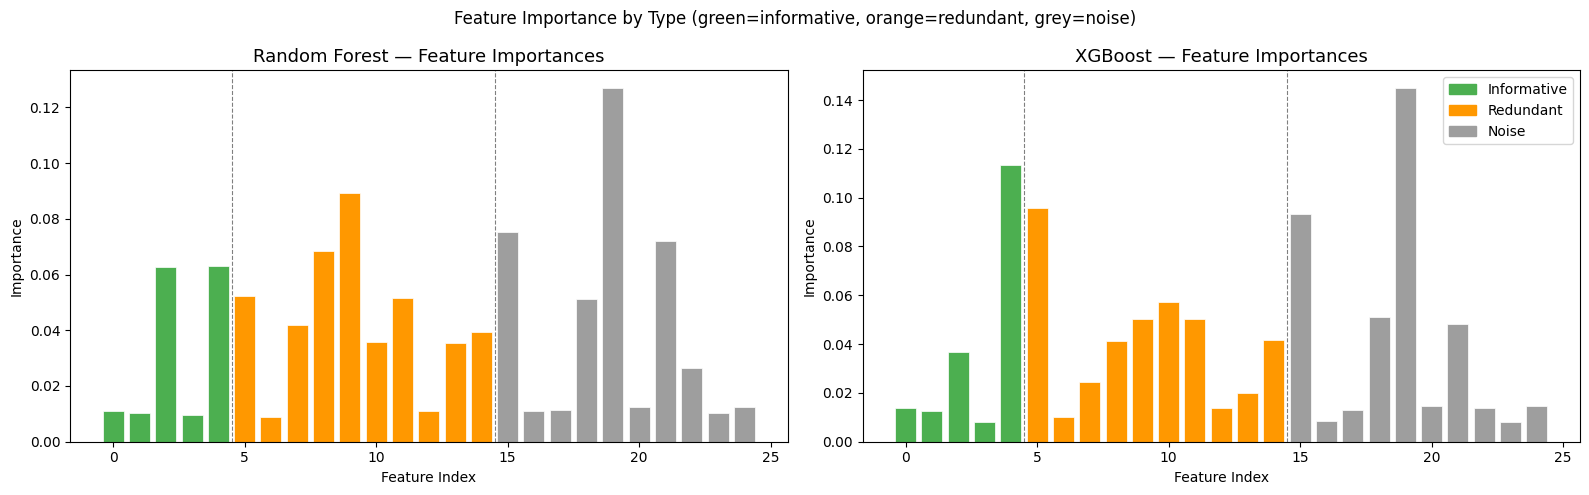

In [22]:
rf_fi = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
xgb_fi = XGBClassifier(n_estimators=200, eval_metric='logloss', random_state=RANDOM_STATE)
rf_fi.fit(X_hd_tr, y_hd_tr)
xgb_fi.fit(X_hd_tr, y_hd_tr)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x_pos = np.arange(25)
bar_colors = [feature_colors[t] for t in feature_types]

for ax, model, importances, label, color in [
    (axes[0], rf_fi,  rf_fi.feature_importances_,  "Random Forest",  RF_COLOR),
    (axes[1], xgb_fi, xgb_fi.feature_importances_, "XGBoost",        XGB_COLOR),
]:
    ax.bar(x_pos, importances, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f"{label} — Feature Importances", fontsize=13)
    ax.set_xlabel("Feature Index")
    ax.set_ylabel("Importance")
    ax.axvline(4.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(14.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

legend_patches = [mpatches.Patch(color=v, label=k.capitalize()) for k, v in feature_colors.items()]
axes[1].legend(handles=legend_patches, loc='upper right')
fig.suptitle("Feature Importance by Type (green=informative, orange=redundant, grey=noise)", fontsize=12)
plt.tight_layout()
plt.show()


### Overfitting on Noise: The Regularisation Tax

With 20 non-informative features available, an unconstrained model will find spurious patterns in the training set. XGBoost is particularly vulnerable here: each boosting round can split on any feature, and without explicit penalties the algorithm will happily memorise training noise.

RF has a structural defence — random feature subsampling at each split means noise features appear less often as candidates, and their signal gets diluted across many trees. It's not immune, but the averaging mechanism limits the damage.

We compare three configurations:
- **RF (default)** — the baseline; implicit regularisation via bootstrap + feature subsampling
- **XGB (defaults removed)** — `reg_lambda=0, reg_alpha=0`. XGBoost ships with `reg_lambda=1` by default, so this configuration deliberately strips out that protection to demonstrate what the boosting algorithm does without any explicit constraint. This is not how you would use XGBoost in practice — it is a controlled illustration of the failure mode.
- **XGB (regularised)** — `reg_lambda=5, reg_alpha=1, subsample=0.8`; stronger explicit penalties plus stochastic row sampling to limit overfitting

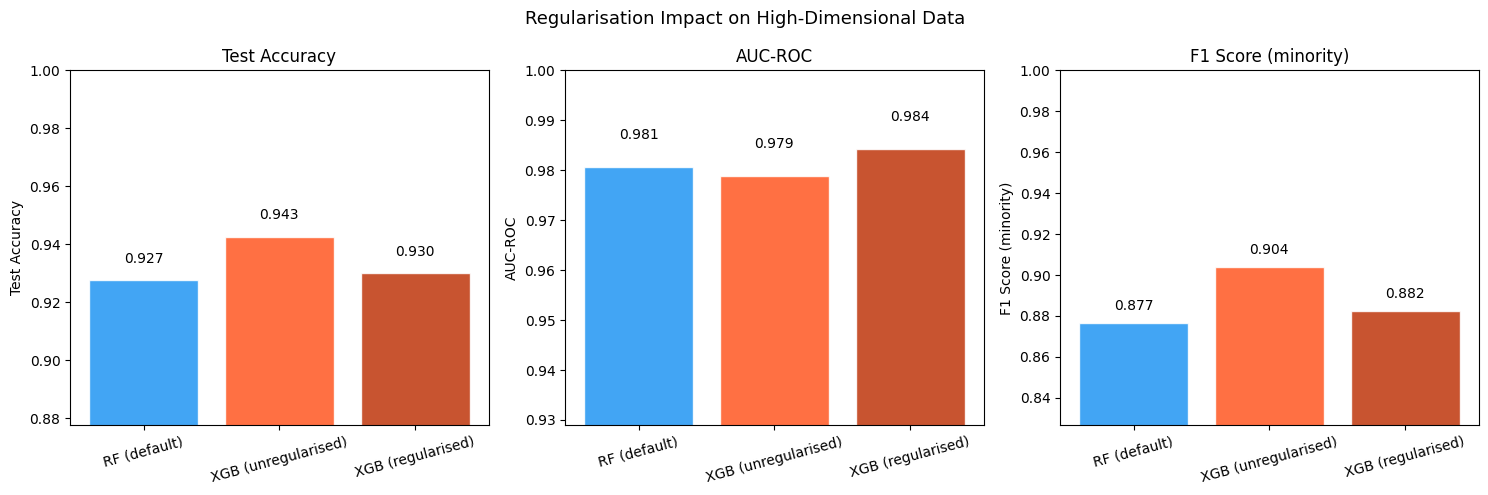


Train accuracy (overfitting indicator):
  RF (default)                   train=1.000  test=0.927  gap=0.073
  XGB (unregularised)            train=1.000  test=0.943  gap=0.057
  XGB (regularised)              train=1.000  test=0.930  gap=0.070


In [23]:
from sklearn.metrics import accuracy_score, f1_score

configs = [
    ("RF (default)",           RF_COLOR,  RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
    ("XGB (defaults removed)", XGB_COLOR, XGBClassifier(n_estimators=200, reg_lambda=0, reg_alpha=0, eval_metric='logloss', random_state=RANDOM_STATE)),
    ("XGB (regularised)",      "#BF360C", XGBClassifier(n_estimators=200, reg_lambda=5, reg_alpha=1, subsample=0.8, eval_metric='logloss', random_state=RANDOM_STATE)),
]

reg_results = []
for name, color, model in configs:
    model.fit(X_hd_tr, y_hd_tr)
    tr_acc = accuracy_score(y_hd_tr, model.predict(X_hd_tr))
    te_acc = accuracy_score(y_hd_te, model.predict(X_hd_te))
    te_auc = roc_auc_score(y_hd_te, model.predict_proba(X_hd_te)[:, 1])
    te_f1  = f1_score(y_hd_te, model.predict(X_hd_te))
    reg_results.append((name, color, tr_acc, te_acc, te_auc, te_f1))

# Bar chart: train vs test accuracy per config
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = [("Test Accuracy", 3), ("AUC-ROC", 4), ("F1 Score (minority)", 5)]

for ax, (metric_name, idx) in zip(axes, metrics):
    names = [r[0] for r in reg_results]
    values = [r[idx] for r in reg_results]
    colors = [r[1] for r in reg_results]
    bars = ax.bar(names, values, color=colors, alpha=0.85, edgecolor='white')
    ax.set_ylim(min(values) - 0.05, 1.0)
    ax.set_title(metric_name, fontsize=12)
    ax.set_ylabel(metric_name)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

fig.suptitle("Regularisation Impact on High-Dimensional Data", fontsize=13)
plt.tight_layout()
plt.show()

# Also print train accuracy to show the overfitting gap
print("\nTrain accuracy (overfitting indicator):")
for name, _, tr_acc, te_acc, _, _ in reg_results:
    gap = tr_acc - te_acc
    print(f"  {name:<30} train={tr_acc:.3f}  test={te_acc:.3f}  gap={gap:.3f}")

### Class Imbalance: Who Gets Left Behind?

With a 70/30 split a naive classifier can achieve 70% accuracy by predicting the majority class every time. Both models can fall into this trap — but they fall differently.

**RF** averages votes across trees. On imbalanced data, the majority class dominates most bootstrap samples, so most trees vote majority — the minority class gets outvoted. The fix: `class_weight='balanced'` reweights each sample inversely proportional to class frequency, forcing each tree to treat the classes equally.

**XGBoost** corrects residuals sequentially. If the initial prediction is biased toward the majority class, subsequent trees correct majority-class errors more than minority-class ones (because there are more of them). The fix: `scale_pos_weight = n_negative / n_positive` scales the gradient and hessian of positive-class samples upward so that the minority class contributes proportionally to each boosting update. XGBoost's documentation recommends this exact ratio for binary classification with logloss — it re-balances the effective class frequencies without changing the model's decision threshold.

F1 score on the minority class is a sharper measure than overall accuracy here.

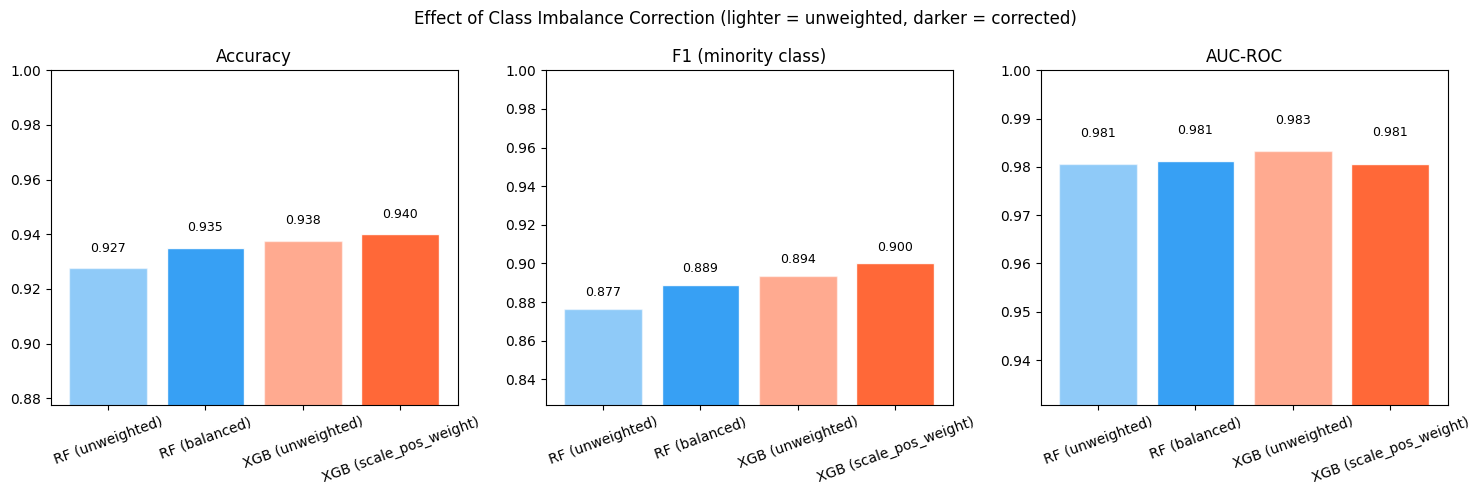

In [24]:
neg, pos = np.bincount(y_hd_tr)
# XGBoost docs recommend neg/pos for binary logloss: equalises effective class frequency
scale_pos = neg / pos

imbalance_configs = [
    ("RF (unweighted)",    RF_COLOR,  RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
    ("RF (balanced)",      RF_COLOR,  RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE)),
    ("XGB (unweighted)",   XGB_COLOR, XGBClassifier(n_estimators=200, eval_metric='logloss', random_state=RANDOM_STATE)),
    ("XGB (scale_pos_weight)", XGB_COLOR, XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos, eval_metric='logloss', random_state=RANDOM_STATE)),
]

imb_results = []
for name, color, model in imbalance_configs:
    model.fit(X_hd_tr, y_hd_tr)
    preds = model.predict(X_hd_te)
    imb_results.append({
        'name': name, 'color': color,
        'accuracy': accuracy_score(y_hd_te, preds),
        'f1_minority': f1_score(y_hd_te, preds),
        'auc': roc_auc_score(y_hd_te, model.predict_proba(X_hd_te)[:, 1]),
    })

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = [("Accuracy", 'accuracy'), ("F1 (minority class)", 'f1_minority'), ("AUC-ROC", 'auc')]

for ax, (metric_name, key) in zip(axes, metrics):
    names = [r['name'] for r in imb_results]
    values = [r[key] for r in imb_results]
    colors = [r['color'] for r in imb_results]
    alphas = [0.5, 0.9, 0.5, 0.9]
    bars = ax.bar(names, values, color=colors, alpha=0.85, edgecolor='white')
    for bar, alpha in zip(bars, alphas):
        bar.set_alpha(alpha)
    ax.set_ylim(min(values) - 0.05, 1.0)
    ax.set_title(metric_name, fontsize=12)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle("Effect of Class Imbalance Correction (lighter = unweighted, darker = corrected)", fontsize=12)
plt.tight_layout()
plt.show()

### Observations

**Feature importance:** RF tends to spread importance more evenly across correlated features — because any of the redundant features can proxy for the informative ones, each gets partial credit. XGBoost's gain metric is more decisive: it concentrates importance on whichever feature of a correlated group gives the largest single loss reduction.

**Regularisation:** The train/test accuracy gap for unregularised XGBoost is the tell — high training accuracy with a larger drop at test time signals that boosting is fitting noise. Adding `reg_lambda` and `reg_alpha` closes that gap. RF's gap is smaller by default, but it's not free: if you let individual trees grow unconstrained (`max_depth=None`) on very noisy data, variance creeps back in.

**Class imbalance:** Accuracy is nearly useless as a metric here — an unweighted model can score well by ignoring the minority class entirely. F1 on the minority class exposes this. Both weighting strategies (`class_weight='balanced'` for RF, `scale_pos_weight` for XGBoost) improve minority-class recall at the cost of some majority-class precision — the right tradeoff depends on your problem's cost asymmetry.


## Section 9 — Summary

In [25]:
from IPython.display import display, Markdown

summary_models = [
    ("RF", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ("XGB", XGBClassifier(n_estimators=100, eval_metric="logloss",
                           random_state=RANDOM_STATE, verbosity=0)),
]

summary_results = {}
for model_label, model in summary_models:
    for ds_name, (X_tr, X_te, y_tr, y_te) in datasets.items():
        t0 = time.time()
        model.fit(X_tr, y_tr)
        fit_time = time.time() - t0
        acc = model.score(X_te, y_te)
        auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
        summary_results[(model_label, ds_name)] = {"acc": acc, "auc": auc, "time": fit_time}

rf_m  = summary_results[("RF",  "Moons")]
rf_l  = summary_results[("RF",  "Linear")]
xgb_m = summary_results[("XGB", "Moons")]
xgb_l = summary_results[("XGB", "Linear")]

table = f"""
| Metric | RF — Moons | RF — Linear | XGB — Moons | XGB — Linear |
|---|---|---|---|---|
| Test Accuracy | {rf_m['acc']:.3f} | {rf_l['acc']:.3f} | {xgb_m['acc']:.3f} | {xgb_l['acc']:.3f} |
| AUC-ROC | {rf_m['auc']:.3f} | {rf_l['auc']:.3f} | {xgb_m['auc']:.3f} | {xgb_l['auc']:.3f} |
| Fit Time (s) | {rf_m['time']:.3f} | {rf_l['time']:.3f} | {xgb_m['time']:.3f} | {xgb_l['time']:.3f} |
"""
display(Markdown(table))


| Metric | RF — Moons | RF — Linear | XGB — Moons | XGB — Linear |
|---|---|---|---|---|
| Test Accuracy | 0.950 | 0.920 | 0.940 | 0.910 |
| AUC-ROC | 0.989 | 0.973 | 0.996 | 0.969 |
| Fit Time (s) | 0.046 | 0.043 | 0.165 | 0.157 |


### Rules of Thumb: When to Choose Each Model

#### Choose Random Forest when:

- **Limited time to tune**: RF is robust with defaults. `n_estimators=100` and `max_features="sqrt"` work well on most problems without any hyperparameter search.
- **Noisy data**: The ensemble averaging mechanism dampens the effect of outliers and label noise — individual trees may memorise noisy examples, but the majority vote/average overwhelms them.
- **Explainability matters**: Feature importances from RF are straightforward to compute and explain (mean impurity decrease, or permutation importance). The model's behaviour is easier to reason about for stakeholders.
- **Smaller datasets**: On small N, boosting's ability to drive training error to zero becomes a liability — RF's regularisation-by-averaging is safer when you can't afford a large hold-out set for hyperparameter tuning.

#### Choose XGBoost when:

- **You need every last bit of accuracy on structured/tabular data**: XGBoost's bias-reduction architecture consistently outperforms RF on well-tuned problems with sufficient data.
- **You have time and data to tune regularisation parameters**: `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda` — when properly tuned, these unlock XGBoost's full potential.
- **The dataset is large enough**: Boosting's advantage over bagging grows with dataset size; on very small datasets, the variance amplified by residual-fitting can dominate.
- **You're competing in a Kaggle competition**: XGBoost (and its successors LightGBM, CatBoost) has dominated structured data competitions for over a decade. It is, for practical purposes, the default answer for tabular ML.